In [ ]:
import os
import sys

# Detect environment and set project root directory
if 'google.colab' in sys.modules:
    print("Running in Google Colab")
    from google.colab import drive
    drive.mount('/content/drive')
    # If running in Colab, point to your mounted drive directory
    ROOT_DIR = "/content/drive/My Drive/Colab Notebooks/Pacific Dataviz Challenge 2026/"
else:
    print("Running in Local / GitHub environment")
    # Dynamically sets root to wherever this notebook file lives
    ROOT_DIR = os.path.dirname(os.path.abspath(__file__)) if '__file__' in globals() else os.getcwd()

Current environment: Google Colab Virtual Machine
Mounted at /content/drive


In [ ]:
# Data architecture

# Processed data
PROCESSED_DATA_DIR = os.path.join(ROOT_DIR, "data", "processed")

# Models
MODELS_DIR = os.path.join(ROOT_DIR, "models")

# Verification print
print(f"Target Root Directory successfully mapped to: {ROOT_DIR}")
print(f"Processed Data Directory mapped to: {PROCESSED_DATA_DIR}")
print(f"Models Directory mapped to: {MODELS_DIR}")

Target Root Directory successfully mapped to: /content/drive/My Drive/Colab Notebooks/Pacific Dataviz Challenge 2026/
Processed Data Directory mapped to: /content/drive/My Drive/Colab Notebooks/Pacific Dataviz Challenge 2026/data/processed
Models Directory mapped to: /content/drive/My Drive/Colab Notebooks/Pacific Dataviz Challenge 2026/models


In [ ]:
import pandas as pd
import numpy as np

# Import preprocessed data
df = os.path.join(PROCESSED_DATA_DIR, "master_df.csv")
df = pd.read_csv(df)

# Select features for K-Means
kmeans_features = [
    'Log_Population',          # Scale
    'Tourism_Per_Capita',      # Unskewed per-capita tourism stress
    'Energy_Per_Capita',       # Unskewed per-capita energy stress
    'Renewable_Share'          # Transition state (0-100%)
]

In [ ]:
from sklearn.preprocessing import StandardScaler

# Scale the K-Means features
scaler = StandardScaler()
X_kmeans = scaler.fit_transform(df[kmeans_features])
df_X_kmeans = pd.DataFrame(X_kmeans, columns=[f"{col}_Scaled" for col in kmeans_features])

import joblib

# Save scaler in MODELS_DIR so Streamlit app can use it for new user inputs
joblib.dump(scaler, os.path.join(MODELS_DIR, "scaler.pkl"))

['/content/drive/My Drive/Colab Notebooks/Pacific Dataviz Challenge 2026/models/scaler.pkl']

In [ ]:
# Colours copied from https://pacificdatavizchallenge.org/ using https://imagecolorpicker.com/
palette = {
    0: "#1a2b49",  # Navy
    1: "#7bc7d6",  # Teal
    2: "#6dd1d9",  # Turquoise
    3: "#f0fafd",  # Pale Blue
    4: "#c3976c",  # Sand
}

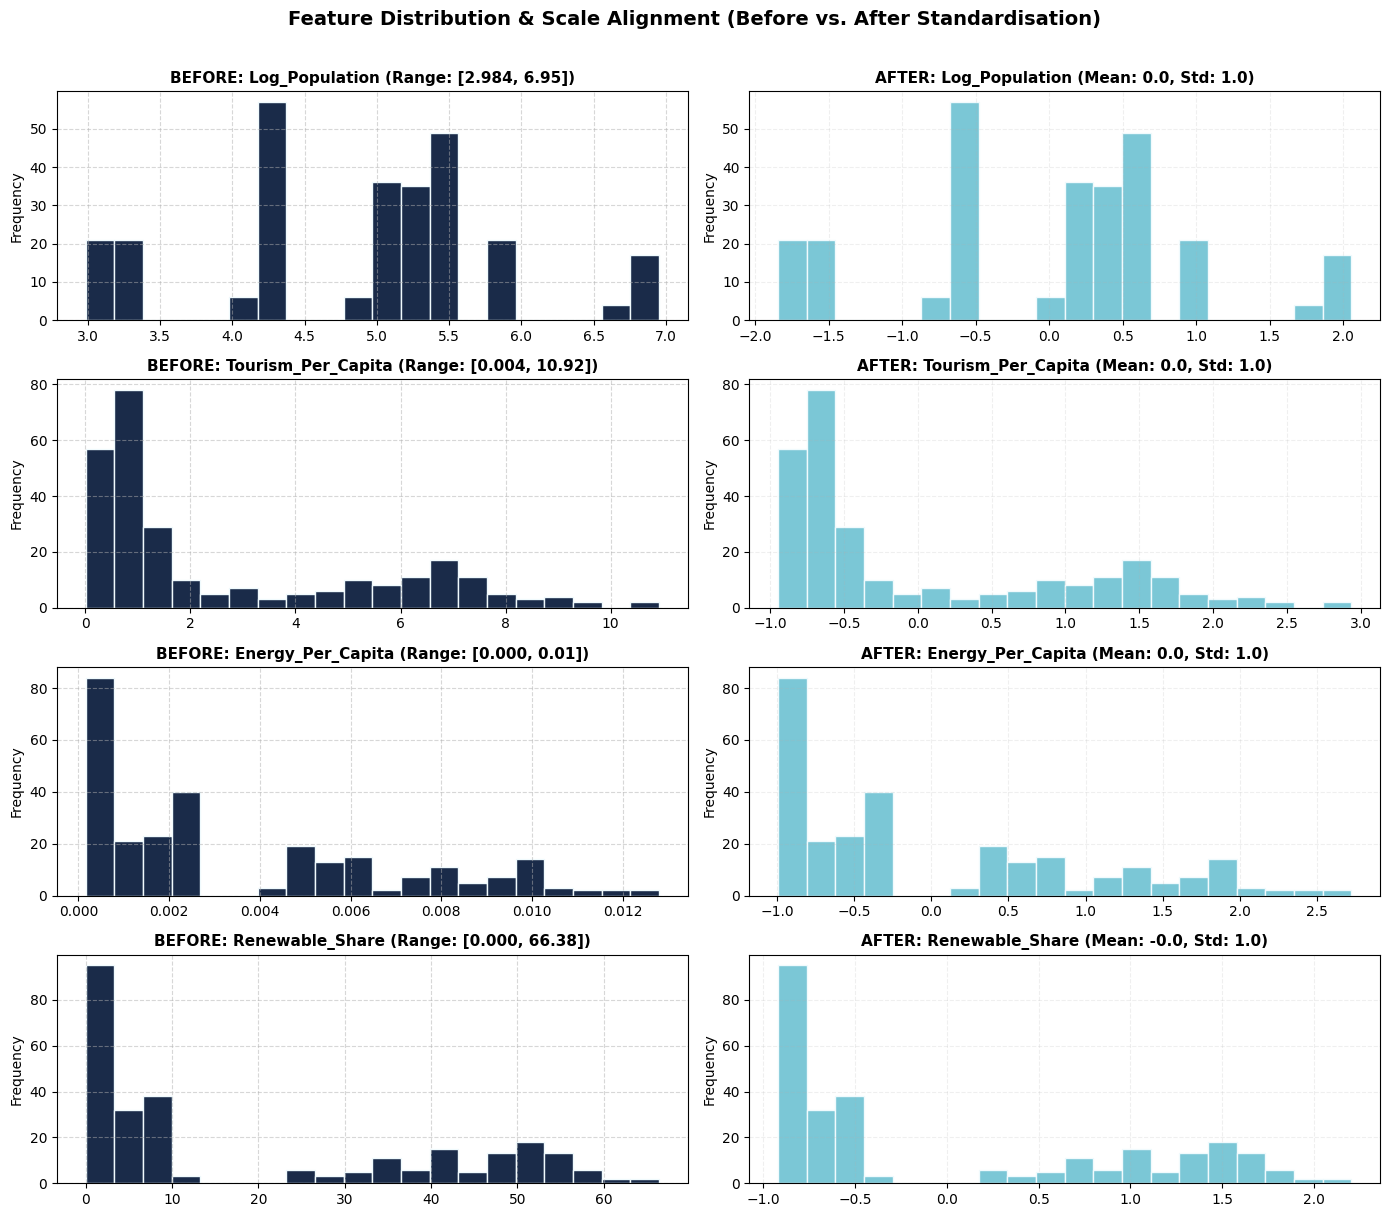

In [ ]:
import matplotlib.pyplot as plt

# --- 3. Build Side-by-Side Comparison Plot ---
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(14, 12))

for i, col in enumerate(kmeans_features):
    scaled_col = f"{col}_Scaled"

    # BEFORE SCALING (Raw Distribution)
    axes[i, 0].hist(
        df[col], bins=20, color=palette[0], edgecolor=palette[3]
    )
    axes[i, 0].set_title(
        f"BEFORE: {col} (Range: [{df[col].min():.3f}, {df[col].max():.2f}])",
        fontsize=11,
        fontweight="bold",
    )
    axes[i, 0].set_ylabel("Frequency")
    axes[i, 0].grid(True, linestyle="--", alpha=0.5)

    # AFTER SCALING (Standardized: Mean=0, Std=1)
    axes[i, 1].hist(
        df_X_kmeans[scaled_col],
        bins=20,
        color= palette[1],
        edgecolor= palette[3],
        )

    axes[i, 1].set_title(
        f"AFTER: {col} (Mean: {df_X_kmeans[scaled_col].mean():.1f}, Std: {df_X_kmeans[scaled_col].std():.1f})",
        fontsize=11,
        fontweight="bold",
    )
    axes[i, 1].set_ylabel("Frequency")
    axes[i, 1].grid(True, linestyle="--", alpha=0.2)

plt.suptitle(
    "Feature Distribution & Scale Alignment (Before vs. After Standardisation)",
    fontsize=14,
    fontweight="bold",
    y=1.01,
)
plt.tight_layout()
plt.show()

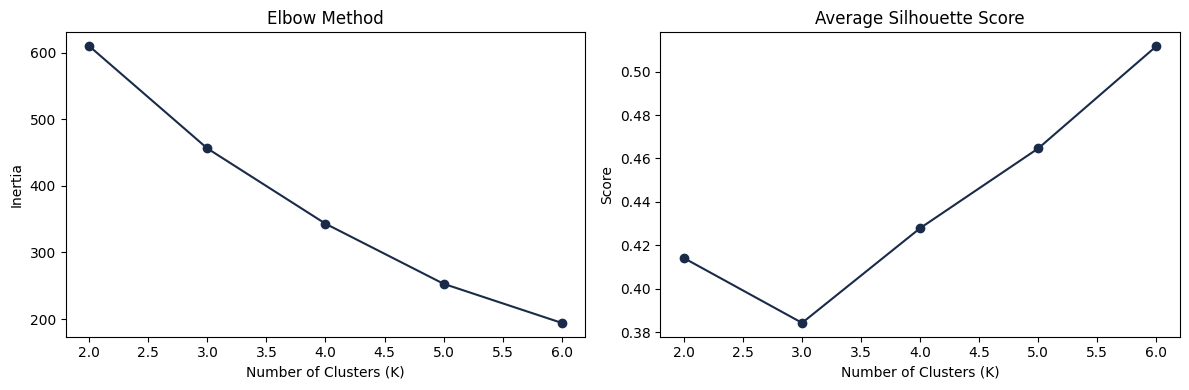

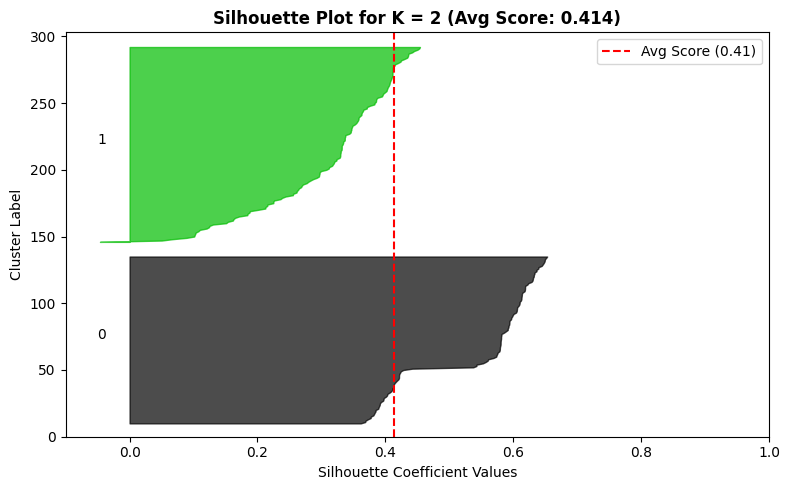

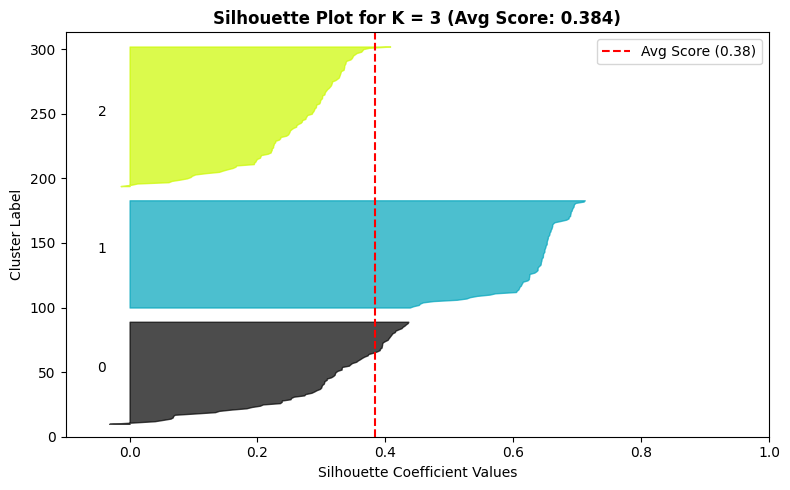

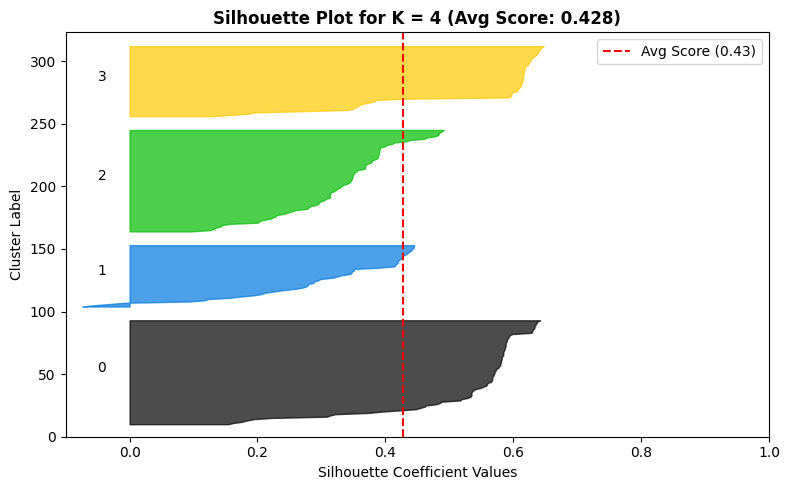

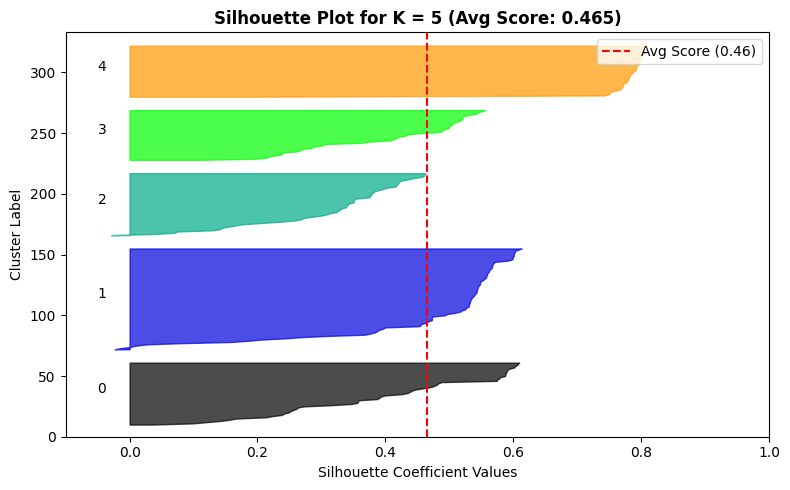

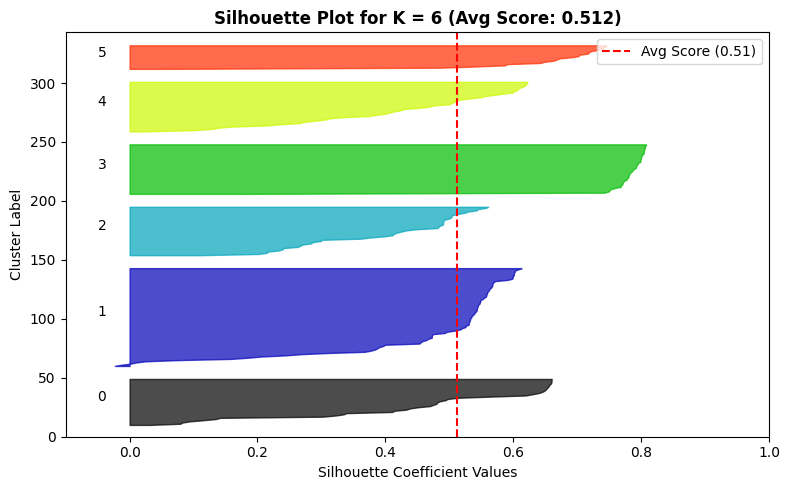

In [ ]:
import matplotlib.cm as cm
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score

# Evaluate Elbow curve and Silhouette scores
inertias = []
silhouette_scores = []
k_range = range(2, 7)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_kmeans)
    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_kmeans, labels))

# Plot Summary: Elbow and average Silhouette score
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(k_range, inertias, marker="o", color=palette[0])
ax[0].set_title("Elbow Method")
ax[0].set_xlabel("Number of Clusters (K)")
ax[0].set_ylabel("Inertia")

ax[1].plot(k_range, silhouette_scores, marker="o", color=palette[0])
ax[1].set_title("Average Silhouette Score")
ax[1].set_xlabel("Number of Clusters (K)")
ax[1].set_ylabel("Score")
plt.tight_layout()
plt.show()

# Silhouette plots for each K
for k in k_range:
    fig, ax = plt.subplots(1, 1, figsize=(8, 5))

    # Initialise model and get labels
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = km.fit_predict(X_kmeans)

    avg_score = silhouette_score(X_kmeans, cluster_labels)
    sample_silhouette_values = silhouette_samples(X_kmeans, cluster_labels)

    ax.set_xlim([-0.1, 1])
    ax.set_ylim([0, len(X_kmeans) + (k + 1) * 10])

    y_lower = 10
    for i in range(k):
        # Aggregate and sort scores for samples in cluster i
        ith_cluster_scores = sample_silhouette_values[cluster_labels == i]
        ith_cluster_scores.sort()

        size_cluster_i = ith_cluster_scores.shape[0]
        y_upper = y_lower + size_cluster_i

        color = cm.nipy_spectral(float(i) / k)
        ax.fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            ith_cluster_scores,
            facecolor=color,
            edgecolor=color,
            alpha=0.7,
        )

        # Label cluster number near y-axis
        ax.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
        y_lower = y_upper + 10

    ax.set_title(
        f"Silhouette Plot for K = {k} (Avg Score: {avg_score:.3f})",
        fontweight="bold",
    )
    ax.set_xlabel("Silhouette Coefficient Values")
    ax.set_ylabel("Cluster Label")

    # Draw dashed vertical line for average score across all clusters
    ax.axvline(
        x=avg_score,
        color="red",
        linestyle="--",
        label=f"Avg Score ({avg_score:.2f})",
    )
    ax.legend(loc="upper right")
    plt.tight_layout()
    plt.show()

In [ ]:
# Fit Final Selected K = 6 Model
# Wanted to only have K = 2, however Silhouette plot showed that clusters were non-optimal
kmeans_model = KMeans(n_clusters=6, random_state=42, n_init=10)
df["Cluster"] = kmeans_model.fit_predict(X_kmeans)

# Breakdown cluster counts
print("Cluster count breakdown:")
print(df["Cluster"].value_counts())

Cluster count breakdown:
Cluster
1    84
4    43
3    43
2    42
0    40
5    21
Name: count, dtype: int64


In [ ]:
location_year_cluster_df = df.copy()

# Pivot for locations by column
location_year_cluster_df = location_year_cluster_df.pivot(
    index='Year',
    columns='Location',
    values='Cluster'
)
location_year_cluster_df.columns.name = None
location_year_cluster_df.index.name = 'Year'
location_year_cluster_df


,Cook Islands,Fiji,French Polynesia,Guam,Kiribati,New Caledonia,Niue,Palau,Papua New Guinea,Samoa,Tonga,Tuvalu,Vanuatu
Year,,,,,,,,,,,,,
2000,4,1,3,2,1,2,0,0,1,5,3,0,1
2001,4,1,3,2,1,2,0,0,1,5,3,0,1
2002,4,1,3,2,1,2,0,0,1,5,3,0,1
2003,4,1,3,2,1,2,0,0,1,5,3,0,1
2004,4,1,3,2,1,2,0,4,1,5,3,0,1
2005,4,1,3,2,1,2,0,4,1,5,3,0,1
2006,4,1,3,2,1,2,0,4,1,5,3,0,1
2007,4,1,3,2,1,2,0,4,1,5,3,0,1
2008,4,1,3,2,1,2,0,4,1,5,3,0,1


In [ ]:
# Export cluster data (including 2020)
output_csv_path = os.path.join(PROCESSED_DATA_DIR, "location_year_cluster.csv")

# Save to csv
df.to_csv(output_csv_path, index=False)

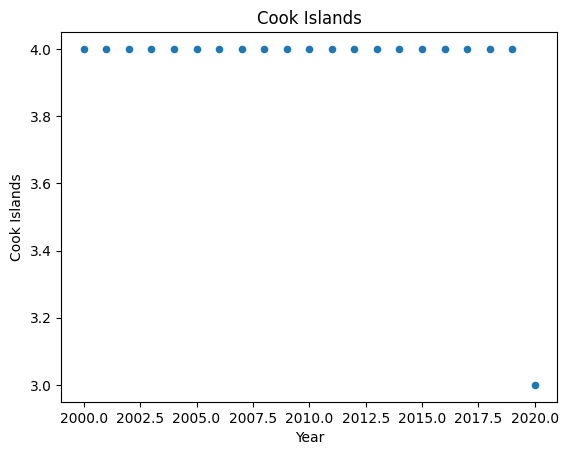

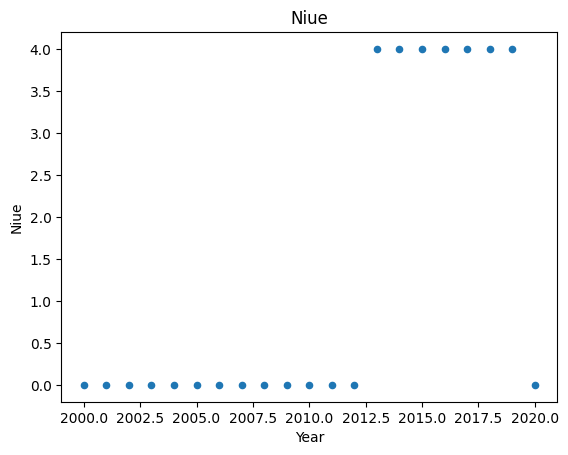

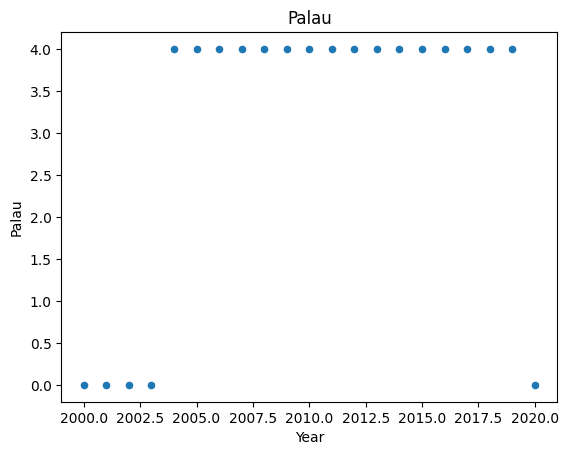

In [ ]:
# Check for locations which move between clusters
variance = location_year_cluster_df.describe()
variance = variance[variance.columns[variance.loc['std'] > 0]]

# Check variance to decide how they should be used in the modelling
for location in variance:
  # Convert the Series to a DataFrame with 'Year' as a column
  temp_df = location_year_cluster_df[location].reset_index()
  plot = temp_df.plot(x='Year', y=location, kind='scatter', title=location)

# The changes in 2020 are representative of the tourism impact from COVID
# The 2020 data is therfore not representative of the actual cluster alignment that a location has under normal circumstances
# 2020 data will therefore be dropped for all locations
# The change in cluster for Niue and Palau represents actual changes in cluster alignment

In [ ]:
# Drop 2020
df = df[df['Year'] != 2020]

In [ ]:
# Compare raw unscaled metrics across the clusters
cluster_profile = df.groupby('Cluster')[[
    'Calculated_Population',
    'Tourism_Aggregated_Arrivals',
    'Energy_Generation',
    'Renewable_Share',
    'Tourism_Per_Capita'
]].mean()

print ('Unscaled cluster averages')
display(cluster_profile.round(2))

Unscaled cluster averages


,Calculated_Population,Tourism_Aggregated_Arrivals,Energy_Generation,Renewable_Share,Tourism_Per_Capita
Cluster,,,,,
0,3244.62,8497.30,15.57,1.18,1.99
1,2018002.95,267093.50,962.34,46.00,0.50
2,214125.05,807850.00,2038.82,3.45,4.23
3,183054.20,144200.00,356.90,4.76,0.74
4,14569.26,91913.95,50.16,4.31,6.28
5,18168.85,124520.00,121.14,43.72,6.81


In [ ]:
# Map cluster IDs to semantics
cluster_names = {
    0: "Minimal Grid Infrastructure / Low Renewable",  # Low population, moderate tourism per capita, minimal energy generation (15.6 GWh), lowest renewable share (1.18%)
    1: "Highest Renewable",  # Dominant population base, large energy generation (962 GWh), highest renewable share (46.0%)
    2: "Largest Grid Infrastructure",  # High tourist volume (807k), massive total energy generation (2,039 GWh), low renewable share (3.45%)
    3: "Medium Grid Infrastructure / Low Renewable",  # Mid-sized population, low tourism intensity (0.74/capita), moderate demand (357 GWh), low renewables (4.76%)
    4: "High Tourism / Low Renewable",  # High tourism intensity (6.28/capita), low population, low renewable share (4.31%)
    5: "High Tourism / High Renewable",  # Highest tourism intensity (6.81/capita), small population, strong renewable share (43.72%)
}

# The change in cluster for Niue and Palau represents an increase in tourism and a corresponding energy demand
# Infrastructure developments across Niue and Palau have been limited in terms of improved renewable capacity

df['Cluster_Name'] = df['Cluster'].map(cluster_names)

In [ ]:
def assign_macro_cluster(row):
    if row['Cluster'] == 1 or row['Cluster'] == 3:
        return 'A', 'Population Driven Grids'
    else:
        return 'B', 'Tourism Peaked Grids'

df[['Macro_Cluster', 'Macro_Cluster_Name']] = df.apply(assign_macro_cluster, axis=1, result_type='expand')

In [ ]:
# Add land area km2 to df

location_dict= {
    'Cook Islands' : 236,
    'Fiji' : 18274,
    'French Polynesia' : 3827,
    'Guam' : 544,
    'Kiribati' : 811,
    'New Caledonia' : 18275,
    'Niue' : 260,
    'Palau' : 459,
    'Papua New Guinea' : 452860,
    'Samoa': 2831,
    'Tonga' : 717,
    'Tuvalu': 26,
  'Vanuatu': 12189
}

df["Land_Area_KM2"] = df["Location"].map(location_dict)

In [ ]:
# Base Land Densities
df["Population_Density"] = df["Calculated_Population"] / df["Land_Area_KM2"]
df["Tourist_Spatial_Density"] = (df["Tourism_Aggregated_Arrivals"] / df["Land_Area_KM2"])

# Energy Spatial Densities (GWh to MWh conversion for easier readability)
df["Energy_Density_MWh_KM2"] = (df["Energy_Generation"] * 1000) / df["Land_Area_KM2"]

df["Renewable_Energy_Density_MWh_KM2"] = ((df["Energy_Generation"] * (df["Renewable_Share"] / 100.0)) * 1000) / df["Land_Area_KM2"]

# Log transformed versions for visualisations
df["Log_Population_Density"] = np.log1p(df["Population_Density"])
df["Log_Tourist_Spatial_Density"] = np.log1p(df["Tourist_Spatial_Density"])

In [ ]:
df

,Location,Year,Calculated_Population,Renewable_Share,Energy_Generation,Tourism_Aggregated_Arrivals,Log_Population,Log_Energy,Log_Tourism,Tourism_Per_Capita,...,Cluster_Name,Macro_Cluster,Macro_Cluster_Name,Land_Area_KM2,Population_Density,Tourist_Spatial_Density,Energy_Density_MWh_KM2,Renewable_Energy_Density_MWh_KM2,Log_Population_Density,Log_Tourist_Spatial_Density
0,Cook Islands,2000,15482,9.28,24.8,73000,4.189827,1.394452,4.863323,4.715153,...,High Tourism / Low Renewable,B,Tourism Peaked Grids,236,65.601695,309.322034,105.084746,9.751864,4.198730,5.737611
1,Cook Islands,2001,14883,9.90,25.9,75000,4.172690,1.413300,4.875061,5.039307,...,High Tourism / Low Renewable,B,Tourism Peaked Grids,236,63.063559,317.796610,109.745763,10.864831,4.159876,5.764553
2,Cook Islands,2002,14625,12.25,27.8,73000,4.165096,1.444045,4.863323,4.991453,...,High Tourism / Low Renewable,B,Tourism Peaked Grids,236,61.970339,309.322034,117.796610,14.430085,4.142664,5.737611
3,Cook Islands,2003,14680,11.07,29.2,78000,4.166726,1.465383,4.892095,5.313351,...,High Tourism / Low Renewable,B,Tourism Peaked Grids,236,62.203390,330.508475,123.728814,13.696780,4.146358,5.803653
4,Cook Islands,2004,14729,10.40,29.8,83000,4.168173,1.474216,4.919078,5.635142,...,High Tourism / Low Renewable,B,Tourism Peaked Grids,236,62.411017,351.694915,126.271186,13.132203,4.149638,5.865603
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
267,Vanuatu,2015,262401,35.62,67.0,287000,5.418965,1.826075,5.457882,1.093746,...,Highest Renewable,A,Population Driven Grids,12189,21.527689,23.545820,5.496759,1.957946,3.114745,3.200542
268,Vanuatu,2016,268305,33.10,75.2,351580,5.428629,1.876218,5.546024,1.310374,...,Highest Renewable,A,Population Driven Grids,12189,22.012060,28.844040,6.169497,2.042104,3.136018,3.395985
269,Vanuatu,2017,274637,35.35,79.8,332800,5.438759,1.902003,5.522183,1.211781,...,Highest Renewable,A,Population Driven Grids,12189,22.531545,27.303306,6.546887,2.314324,3.158342,3.342979
270,Vanuatu,2018,281311,29.40,81.5,350200,5.449187,1.911158,5.544316,1.244886,...,Highest Renewable,A,Population Driven Grids,12189,23.079088,28.730823,6.686357,1.965789,3.181344,3.392184


In [ ]:
# Export preprocessed data
output_csv_path = os.path.join(PROCESSED_DATA_DIR, "master_clustered_df.csv")

# Save to csv
df.to_csv(output_csv_path, index=False)

# Save kmeans in MODELS_DIR so Streamlit app can use it for new user inputs
joblib.dump(kmeans_model, os.path.join(MODELS_DIR, "kmeans_model.pkl"))

['/content/drive/My Drive/Colab Notebooks/Pacific Dataviz Challenge 2026/models/kmeans_model.pkl']

In [ ]:
# Define target metrics to track over time
target_cols = [
    "Renewable_Share",
    "Energy_Generation",
    "Tourism_Aggregated_Arrivals",
    "Calculated_Population",
    "Total_Human_Load",
    "Tourist_Spatial_Density",
    "Energy_Density_MWh_KM2",
]

# Build micro cluster time series df
micro_ts = (
    df.groupby(["Cluster", "Year"])[target_cols]
    .agg(["mean", "median"])
    .reset_index()
)

# Flatten multi index columns
micro_ts.columns = [
    f"{col[0]}_{col[1]}".strip("_") for col in micro_ts.columns
]

micro_ts

# Build macro cluster time series df
macro_ts = (
    df.groupby(["Macro_Cluster", "Year"])[target_cols]
    .agg(["mean", "median"])
    .reset_index()
)

# Flatten MultiIndex columns
macro_ts.columns = [
    f"{col[0]}_{col[1]}".strip("_") for col in macro_ts.columns
]

output_micro_path = os.path.join(PROCESSED_DATA_DIR, "micro_cluster_timeseries.csv")
output_macro_path = os.path.join(PROCESSED_DATA_DIR, "macro_cluster_timeseries.csv")

# Save master aggregated outputs to pre-processed path
micro_ts.to_csv(output_micro_path, index=False)
macro_ts.to_csv(output_macro_path, index=False)